# Improved Rock Genre Music Training Notebook
**Purpose:** This notebook provides a robust, production-ready training pipeline for
symbolic music (MIDI) generation. It fixes common issues: invalid tokens, missing durations,
REST handling, token validation, sequence creation, model architecture (BiLSTM + Attention),
training with validation, checkpoints, and saving of artifact files compatible with your app.

**How to use:** Place your MIDI files under `data/rock_midis/` (one folder). Run the cells in order.


In [2]:
# 1. Setup & imports
import os
import glob
import pickle
import random
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import music21 as m21
import tensorflow as tf

layers = tf.keras.layers
models = tf.keras.models
optimizers = tf.keras.optimizers
callbacks = tf.keras.callbacks

import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("music21:", m21.__version__)

# Create folders
os.makedirs("data/jazz", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


TensorFlow: 2.18.0
music21: 9.7.1


## 2. MIDI parsing: extract notes + durations
This parser extracts note/chord symbols including octave and duration tokens, and explicit REST tokens.
It produces tokens like `C4_q` (quarter), `E4_e` (eighth), `C4.E4.G4_q` (chord quarter), and `REST_q`.

In [3]:
# Parser utilities
def duration_symbol(q_len):
    """Map quarterLength to a coarse rhythmic token."""
    # Quantize durations to common values
    # e.g., 0.25 (16th), 0.5 (8th), 1.0 (quarter), 2.0 (half), 4.0 (whole)
    options = [0.25, 0.5, 1.0, 2.0, 4.0]
    diffs = [abs(q_len - o) for o in options]
    idx = int(np.argmin(diffs))
    mapping = {0: '16', 1: '8', 2: 'q', 3: 'h', 4: 'w'}
    return mapping[idx]

def note_to_token(elem):
    """Convert a music21 note or chord to a token with duration symbol."""
    q = float(elem.quarterLength) if hasattr(elem, 'quarterLength') else 1.0
    dur = duration_symbol(q)
    if isinstance(elem, m21.note.Note):
        pitch = elem.pitch
        token = f"{pitch.nameWithOctave}_{dur}"
        return token
    elif isinstance(elem, m21.chord.Chord):
        # join pitch tokens by '.'
        parts = [p.nameWithOctave for p in elem.pitches]
        token = f"{'.'.join(parts)}_{dur}"
        return token
    return None

def extract_tokens_from_midi(path):
    """Return a list of tokens from a MIDI file including REST tokens."""
    tokens = []
    try:
        s = m21.converter.parse(path)
    except Exception as e:
        print(f"Failed to parse {path}: {e}")
        return tokens

    # Flatten parts and get all events with offset and duration
    flat = s.flat.notesAndRests
    for elem in flat:
        if isinstance(elem, m21.note.Rest):
            dur = duration_symbol(float(elem.quarterLength))
            tokens.append(f"REST_{dur}")
        elif isinstance(elem, (m21.note.Note, m21.chord.Chord)):
            tok = note_to_token(elem)
            if tok:
                tokens.append(tok)
    return tokens

# Quick test (requires at least one MIDI in data/rock_midis)
midi_files = glob.glob('data/jazz/**/*.mid', recursive=True) #+ glob.glob('data/rock_midis/*.mid')
print('Found MIDI files:', len(midi_files))
if midi_files:
    sample_tokens = extract_tokens_from_midi(midi_files[0])[:40]
    print('Sample tokens:', sample_tokens)
else:
    print('No MIDI files found. Add MIDI files to data/jazz and re-run this cell.')


Found MIDI files: 50
Sample tokens: ['REST_w', 'REST_w', 'REST_w', 'REST_w', 'REST_h', 'REST_h', 'REST_w', 'B2_8', 'C3_8', 'REST_8', 'F2_16', 'REST_16', 'F2_h', 'REST_8', 'REST_h', 'REST_h', 'F2_w', 'REST_8', 'E3.A3.C4_q', 'REST_16', 'F2_h', 'E3.A3_q', 'C4_h', 'REST_8', 'C4_q', 'REST_8', 'REST_16', 'B-1_16', 'A2_16', 'A1_h', 'B-1_16', 'G3.E-4_h', 'C4_16', 'A2_h', 'REST_w', 'REST_16', 'REST_16', 'REST_16', 'D2_8', 'D3.F#3.C4.E-4_h']


c:\Users\pavan\AppData\Local\Programs\Python\Python311\Lib\site-packages\music21\stream\base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


## 3. Build vocabulary and sequences
This step builds a cleaned vocabulary (only valid notes/chords/rests) and creates sequences
for training with a specified `seq_length`. We also create integer mappings and save them.

In [ ]:
# Build dataset
midi_files = glob.glob('data/jazz/**/*.mid', recursive=True)# + glob.glob('data/rock_midis/*.mid')
all_tokens = []
for p in midi_files:
    all_tokens += extract_tokens_from_midi(p)

print('Total tokens extracted:', len(all_tokens))
counter = Counter(all_tokens)
print('Top 20 tokens:', counter.most_common(20))

# Filter tokens: basic sanity checks
def is_valid_token(t):
    # valid tokens include REST_xx or pitch like C4_q or chords like C4.E4.G4_q
    if not isinstance(t, str) or len(t.strip()) == 0:
        return False
    if t.startswith('REST_'):
        return True
    if '_' not in t:
        return False
    pitch_part, dur = t.rsplit('_', 1)
    # duration must be one of mapped symbols
    if dur not in {'16','8','q','h','w'}:
        return False
    # pitch part for chord: pitches separated by '.'
    parts = pitch_part.split('.')
    for p in parts:
        # require a note letter A-G in string and a digit for octave
        if not any(ch in p for ch in 'ABCDEFG'):
            return False
        if not any(ch.isdigit() for ch in p):
            return False
    return True

vocab = sorted([t for t in counter.keys() if is_valid_token(t)])
print('Filtered vocab size:', len(vocab))

# Save vocab and mappings
token_to_int = {t: i for i, t in enumerate(vocab)}
int_to_token = {i: t for t, i in token_to_int.items()}

with open('jazz_note_mappings_clean.pkl', 'wb') as f:
    pickle.dump((vocab, token_to_int, int_to_token), f)

# Create sequences
seq_length = 64
step = 1
sequences = []
next_tokens = []

# Re-extract tokens per-file to preserve order per song
for p in midi_files:
    toks = [t for t in extract_tokens_from_midi(p) if is_valid_token(t)]
    for i in range(0, max(0, len(toks) - seq_length), step):
        seq = toks[i: i + seq_length]
        target = toks[i + seq_length]
        # convert to ints, if any token not in vocab then skip
        try:
            sequences.append([token_to_int[s] for s in seq])
            next_tokens.append(token_to_int[target])
        except KeyError:
            continue

print('Total sequences:', len(sequences))


Total tokens extracted: 113345
Top 20 tokens: [('REST_16', 27237), ('REST_8', 14008), ('REST_h', 5851), ('REST_q', 5479), ('REST_w', 3125), ('G4_16', 817), ('D2_q', 782), ('C2_q', 700), ('F4_8', 695), ('A4_16', 669), ('F4_16', 663), ('D4_8', 654), ('G2_q', 633), ('D4_16', 618), ('G4_8', 599), ('A4_8', 596), ('D2_8', 595), ('C5_16', 593), ('F2_q', 574), ('C2_8', 568)]
Filtered vocab size: 7399
Total sequences: 110145


In [5]:
# Prepare tf.data dataset
batch_size = 64
buffer_size = 10000

X = np.array(sequences, dtype=np.int32)
y = tf.keras.utils.to_categorical(next_tokens, num_classes=len(vocab))

dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(buffer_size).batch(batch_size, drop_remainder=True)
# split train/val: simple split by number of batches
val_split = 0.1
num_batches = len(list(dataset))
val_batches = max(1, int(num_batches * val_split))
train_dataset = dataset.skip(val_batches)
val_dataset = dataset.take(val_batches)

print('Batches:', num_batches, 'Train batches:', len(list(train_dataset)), 'Val batches:', len(list(val_dataset)))


Batches: 1721 Train batches: 1549 Val batches: 172


## 4. Model architecture
BiLSTM + Attention + Dense output. This is lightweight but stronger than a plain LSTM.

In [6]:
# Model building
vocab_size = len(vocab)
embed_dim = 256
lstm_units = 256

class AttentionLayer(layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, values, query):
        # values: (batch, time, units), query: (batch, units)
        query_with_time = tf.expand_dims(query, 1)  # (batch, 1, units)
        score = self.V(tf.nn.tanh(self.W1(values) + self.W2(query_with_time)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

inputs = layers.Input(shape=(seq_length,), dtype='int32')
x = layers.Embedding(vocab_size, embed_dim)(inputs)
x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=False))(x)
# attention: use final state as query over previous sequence outputs (we reuse last bidir output)
# For simplicity, apply attention over a projected version of embedding+Bidir outputs
proj = layers.Dense(lstm_units)(x)  # query
# Create a small 'values' sequence by re-embedding inputs then a BiLSTM with return_sequences=True
values_seq = layers.Embedding(vocab_size, embed_dim)(inputs)
values_seq = layers.Bidirectional(layers.LSTM(int(lstm_units/2), return_sequences=True))(values_seq)

attn_layer = AttentionLayer(64)
context, attn_weights = attn_layer(values_seq, proj)
concat = layers.Concatenate()([context, x])
out = layers.Dense(512, activation='relu')(concat)
outputs = layers.Dense(vocab_size, activation='softmax')(out)

model = models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 256)   │  1,894,144 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64, 512)   │  1,050,624 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 64, 256)   │  1,894,144 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 512)       │  1,574,912 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 64, 256)   │    394,240 │ embedding_1[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ [(None, 256),     │     32,961 │ bidirectional_2[… │
│ (AttentionLayer)    │ (None, 64, 1)]    │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 768)       │          0 │ attention_layer[… │
│ (Concatenate)       │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    393,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 7399)      │  3,795,687 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,161,768 (42.58 MB)

 Trainable params: 11,161,768 (42.58 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Training callbacks
checkpoint_cb = callbacks.ModelCheckpoint('models/lstm_jazz_best.keras', save_best_only=True, monitor='val_loss', mode='min')
earlystop_cb = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_cb = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=35,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_cb]
)


Epoch 1/35
  17/1549 ━━━━━━━━━━━━━━━━━━━━ 31:33 1s/step - accuracy: 0.2226 - loss: 7.7633

KeyboardInterrupt: 

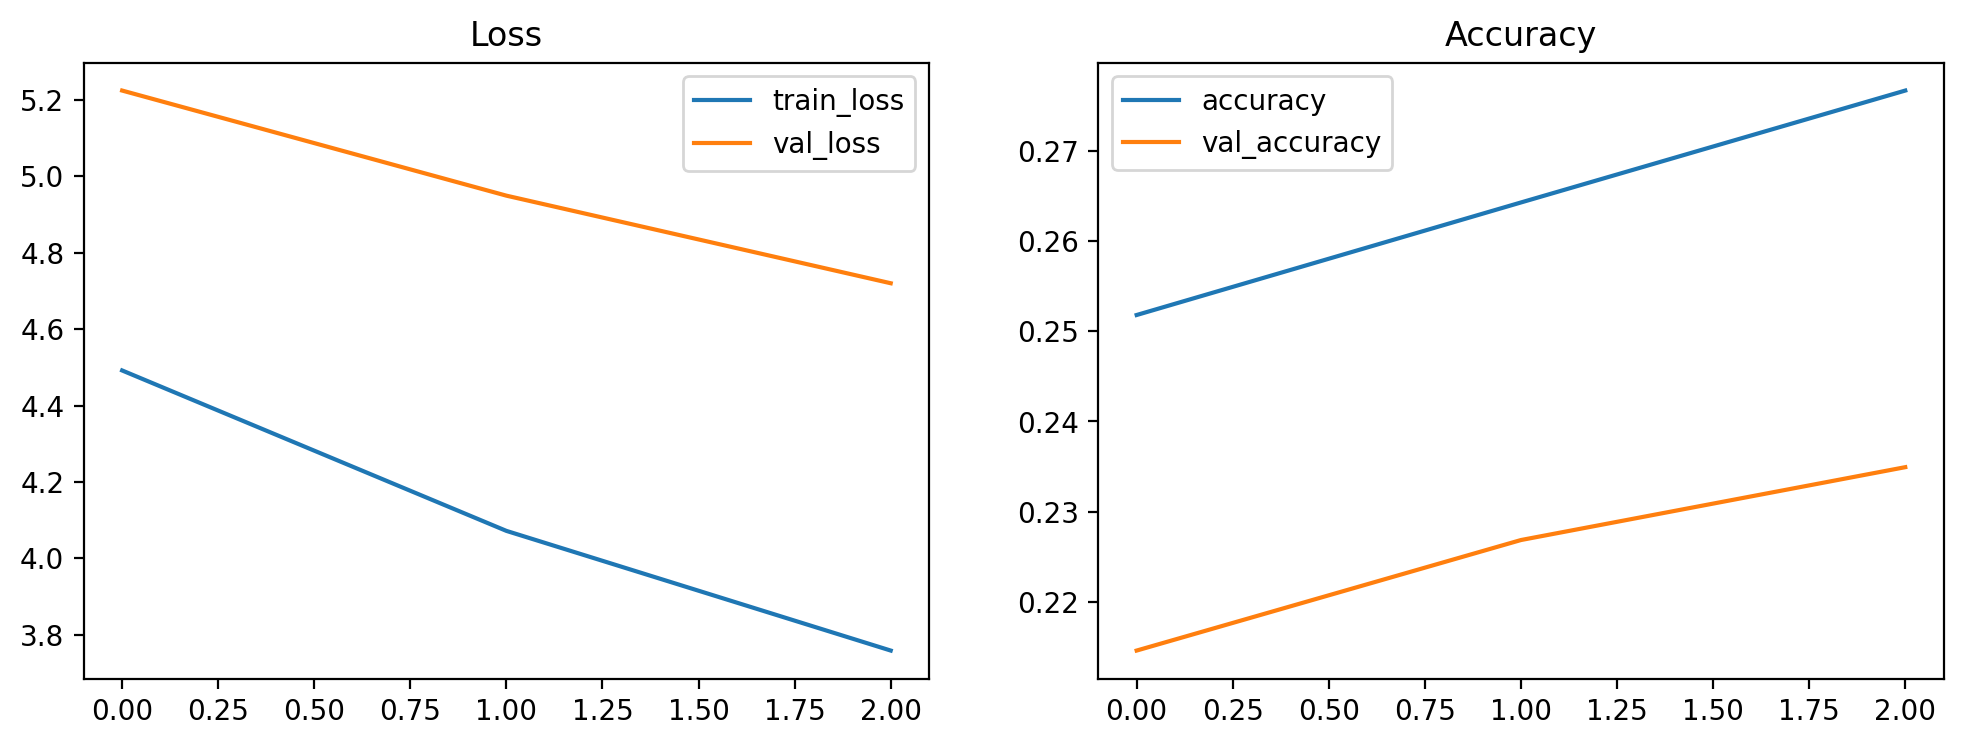

In [8]:
# Save final model & mappings
model.save('models/lstm_jazz_model.keras')
with open('models/jazz_note_mappings.pkl', 'wb') as f:
    pickle.dump((vocab, token_to_int, int_to_token), f)

# Plot history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history.get('accuracy', []), label='accuracy')
plt.plot(history.history.get('val_accuracy', []), label='val_accuracy')
plt.legend(); plt.title('Accuracy')
plt.show()


## 5. Quick inference test
Generate a short sequence from a random seed and save MIDI/WAV for listening.

In [ ]:
# Simple sampler (greedy or temperature sampling)
def sample_from_probs(probs, temperature=1.0):
    probs = np.asarray(probs).astype('float64')
    if temperature <= 0:
        return np.argmax(probs)
    probs = np.log(probs + 1e-12) / temperature
    probs = np.exp(probs - np.max(probs))
    probs /= np.sum(probs)
    return np.random.choice(len(probs), p=probs)

# load mappings
with open('models/rock_note_mappings.pkl','rb') as f:
    vocab, token_to_int, int_to_token = pickle.load(f)

# use best model
m = tf.keras.models.load_model('models/lstm_rock_best.keras', compile=False)

def tokens_to_midi_safe(tokens, out_path='outputs/test_out.mid', bpm=110, note_len_map={'16':0.25,'8':0.5,'q':1.0,'h':2.0,'w':4.0}):
    s = m21.stream.Stream()
    s.append(m21.tempo.MetronomeMark(number=bpm))
    s.append(m21.instrument.Piano())
    offset = 0.0
    for t in tokens:
        if t.startswith('REST_'):
            dur = note_len_map[t.split('_')[-1]]
            offset += dur
            continue
        try:
            pitch_part, dur_sym = t.rsplit('_',1)
            dur = note_len_map.get(dur_sym, 1.0)
            if '.' in pitch_part:
                ch = m21.chord.Chord(pitch_part.split('.'))
                ch.quarterLength = dur
                ch.offset = offset
                s.append(ch)
            else:
                n = m21.note.Note(pitch_part)
                n.quarterLength = dur
                n.offset = offset
                s.append(n)
        except Exception as e:
            offset += 0.5
            continue
        offset += dur
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    s.write('midi', fp=out_path)
    return out_path

# Seed generation
if len(sequences) > 0:
    seed = sequences[np.random.randint(0, len(sequences))]
    generated = []
    cur = list(seed)
    for _ in range(120):  # generate 120 tokens
        inp = np.array([cur[-seq_length:]])
        preds = m.predict(inp)[0]
        idx = sample_from_probs(preds, temperature=0.9)
        token = int_to_token[idx]
        generated.append(token)
        cur.append(idx)
    print('Generated tokens sample:', generated[:40])
    midi_test = tokens_to_midi_safe(generated, out_path='outputs/sample_generated.mid')
    print('Test MIDI saved to', midi_test)
else:
    print('No training sequences found: ensure dataset has enough MIDI files.')
